In [13]:
# 1. Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.decomposition import PCA
from sklearn.svm import SVR

sns.set(style="white")

In [14]:
# 1A. Mount google drive with colab

from google.colab import drive
drive.mount('/content/drive')

# After mounting, verify your files are visible
import os

# Change this path to wherever your folder is in Google Drive
folder_path = '/content/drive/MyDrive/EEG_Thesis_Secondary/'

print("Files found in your folder:")
for f in os.listdir(folder_path):
    print(f" - {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found in your folder:
 - S01HI_features_bandpower_z.csv
 - S01LO_features_bandpower_z.csv
 - S02HI_features_bandpower_z.csv
 - S02LO_features_bandpower_z.csv
 - S03HI_features_bandpower_z.csv
 - S03LO_features_bandpower_z.csv
 - S04HI_features_bandpower_z.csv
 - S04LO_features_bandpower_z.csv
 - S05HI_features_bandpower_z.csv
 - S05LO_features_bandpower_z.csv
 - S06HI_features_bandpower_z.csv
 - S06LO_features_bandpower_z.csv
 - S07HI_features_bandpower_z.csv
 - S07LO_features_bandpower_z.csv
 - S08HI_features_bandpower_z.csv
 - S08LO_features_bandpower_z.csv
 - S09HI_features_bandpower_z.csv
 - S09LO_features_bandpower_z.csv
 - S10HI_features_bandpower_z.csv
 - S10LO_features_bandpower_z.csv
 - S11HI_features_bandpower_z.csv
 - S11LO_features_bandpower_z.csv
 - S12HI_features_bandpower_z.csv
 - S12LO_features_bandpower_z.csv
 - S13HI_features_bandpower

In [15]:
# 2. Setting the data path

import os

# Path to your folder in Google Drive
folder_path = '/content/drive/MyDrive/EEG_Thesis_Secondary/'

# List all CSV files found
all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

print(f"Total CSV files found: {len(all_files)}")
print("\nFiles detected:")
for f in sorted(all_files):
    print(f"  - {f}")

Total CSV files found: 96

Files detected:
  - S01HI_features_bandpower_z.csv
  - S01LO_features_bandpower_z.csv
  - S02HI_features_bandpower_z.csv
  - S02LO_features_bandpower_z.csv
  - S03HI_features_bandpower_z.csv
  - S03LO_features_bandpower_z.csv
  - S04HI_features_bandpower_z.csv
  - S04LO_features_bandpower_z.csv
  - S05HI_features_bandpower_z.csv
  - S05LO_features_bandpower_z.csv
  - S06HI_features_bandpower_z.csv
  - S06LO_features_bandpower_z.csv
  - S07HI_features_bandpower_z.csv
  - S07LO_features_bandpower_z.csv
  - S08HI_features_bandpower_z.csv
  - S08LO_features_bandpower_z.csv
  - S09HI_features_bandpower_z.csv
  - S09LO_features_bandpower_z.csv
  - S10HI_features_bandpower_z.csv
  - S10LO_features_bandpower_z.csv
  - S11HI_features_bandpower_z.csv
  - S11LO_features_bandpower_z.csv
  - S12HI_features_bandpower_z.csv
  - S12LO_features_bandpower_z.csv
  - S13HI_features_bandpower_z.csv
  - S13LO_features_bandpower_z.csv
  - S14HI_features_bandpower_z.csv
  - S14LO_fe

In [16]:
# 3. Load and label all files (Only Secondary)

dfs = []
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        temp = pd.read_csv(os.path.join(folder_path, file))
        temp["label"] = 1 if "HI" in file.upper() else 0
        dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)
print("Total Samples:", len(df))

Total Samples: 2051


In [17]:
# 4. Feature Engineering

X_raw = df.select_dtypes(include=[np.number]).drop(["label"], axis=1, errors="ignore")

X = pd.DataFrame()
X["mean"] = X_raw.mean(axis=1)
X["std"] = X_raw.std(axis=1)
X["var"] = X_raw.var(axis=1)
X["min"] = X_raw.min(axis=1)
X["max"] = X_raw.max(axis=1)
X["range"] = X["max"] - X["min"]

X["energy"] = np.square(X_raw).mean(axis=1)
X["activity_ratio"] = (X["mean"]**2) / (X["std"] + 1e-6)
X["entropy_proxy"] = -np.log1p(np.abs(X_raw)).mean(axis=1)

In [18]:
# 5. Targets
y_class = df["label"]

# Compute y_reg BEFORE X is converted to numpy array in Cell 6
energy = np.square(X_raw).mean(axis=1)   # use X_raw instead of X
std    = X_raw.std(axis=1)

y_reg = energy / (std + 1e-6)

# Clip outliers (1st–99th percentile)
lower = np.percentile(y_reg, 1)
upper = np.percentile(y_reg, 99)
y_reg = np.clip(y_reg, lower, upper)

# Normalize to [0, 1]
y_reg = (y_reg - y_reg.min()) / (y_reg.max() - y_reg.min())

print("y_reg stats:")
print(pd.Series(y_reg).describe())

y_reg stats:
count    2051.000000
mean        0.147451
std         0.149183
min         0.000000
25%         0.074351
50%         0.105529
75%         0.162271
max         1.000000
dtype: float64


In [19]:
# 6. Preprocessing

X = SimpleImputer(strategy="mean").fit_transform(X)
X = StandardScaler().fit_transform(X)

In [20]:
# 7. Feature Selection

selector = SelectKBest(mutual_info_classif, k=min(25, X.shape[1]))
X_selected = selector.fit_transform(X, y_class)

In [21]:
# 8. Classification Models

xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)

rf_clf = RandomForestClassifier(n_estimators=500, class_weight="balanced")
et_clf = ExtraTreesClassifier(n_estimators=600, random_state=42)

clf_model = VotingClassifier(
    estimators=[("xgb", xgb_clf), ("rf", rf_clf), ("et", et_clf)],
    voting="soft"
)

In [27]:
# 9. Regression

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_selected, y_reg, test_size=0.2, random_state=42
)

reg_models = {
    "Random Forest": RandomForestRegressor(n_estimators=300),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300),
    "XGBoost": XGBRegressor(n_estimators=300),
    "SVR": SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.01)
}

print("\nREGRESSION RESULTS")

reg_predictions = {}

for name, model in reg_models.items():
    model.fit(Xr_train, yr_train)
    pred = model.predict(Xr_test)

    reg_predictions[name] = pred

    mae = mean_absolute_error(yr_test, pred)
    rmse = np.sqrt(mean_squared_error(yr_test, pred))
    r2 = r2_score(yr_test, pred)

    print(f"\n{name}")
    print("MAE :", round(mae, 6))
    print("RMSE:", round(rmse, 6))
    print("R2  :", round(r2, 6))


REGRESSION RESULTS

Random Forest
MAE : 0.00415
RMSE: 0.013105
R2  : 0.992053

Extra Trees
MAE : 0.001658
RMSE: 0.003978
R2  : 0.999268

XGBoost
MAE : 0.005565
RMSE: 0.014804
R2  : 0.989858

SVR
MAE : 0.00492
RMSE: 0.008377
R2  : 0.996752


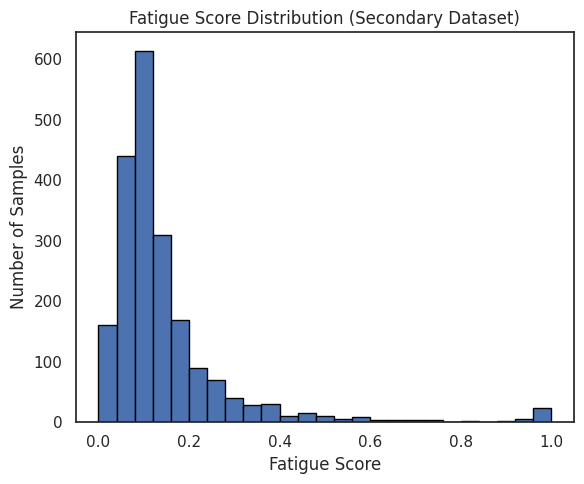

In [23]:
# 10. Fatigue Distribution Plots

plt.figure(figsize=(6,5))
plt.hist(y_reg, bins=25, edgecolor='black')
plt.title("Fatigue Score Distribution (Secondary Dataset)")
plt.xlabel("Fatigue Score")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

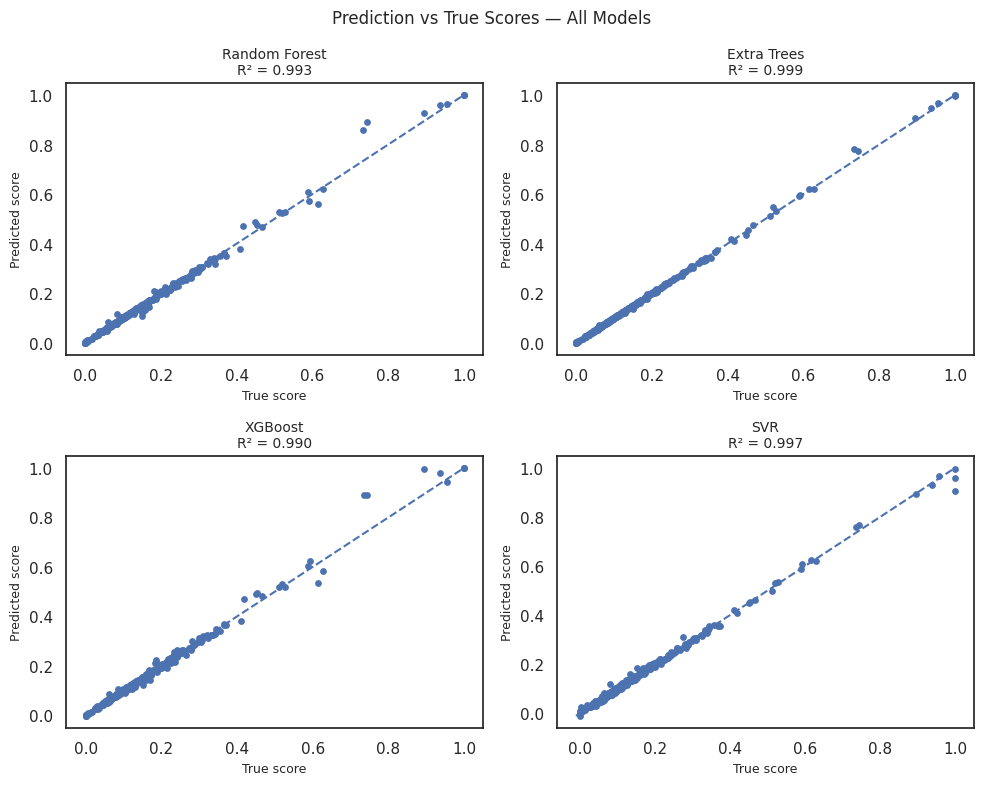

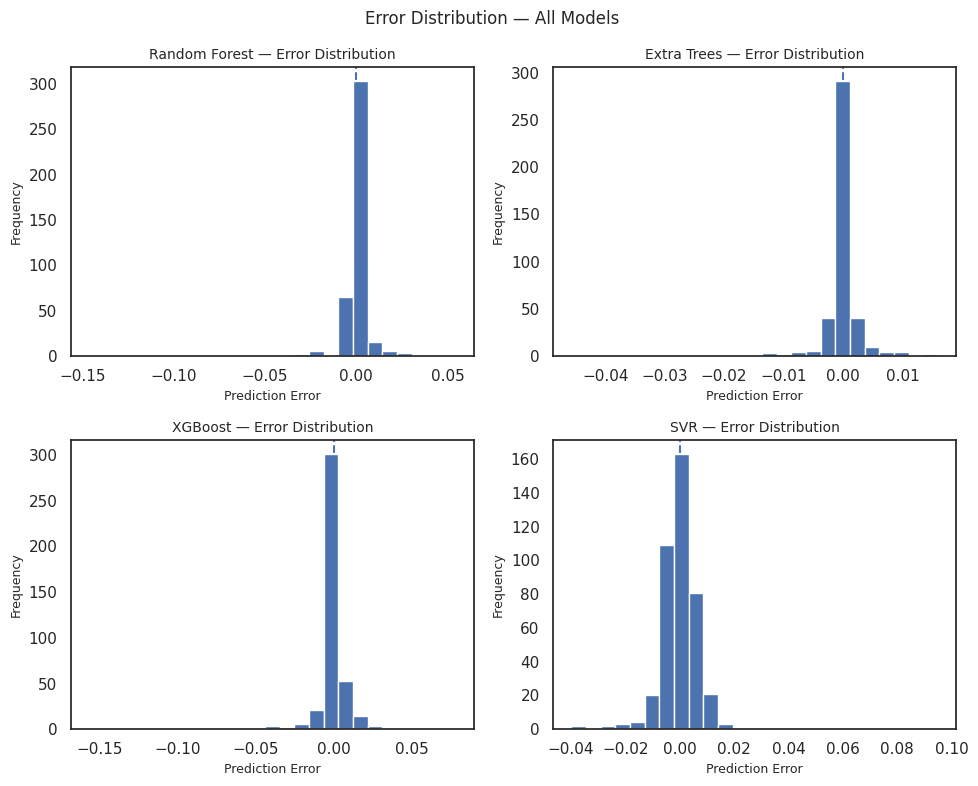

In [25]:
# 11. Plotting

# Fatigue distribution


# Prediction vs True
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (name, pred) in enumerate(reg_predictions.items()):
    ax = axes[i]

    ax.scatter(yr_test, pred, s=15)

    min_val = min(yr_test.min(), pred.min())
    max_val = max(yr_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--')

    r2 = r2_score(yr_test, pred)

    ax.set_title(f"{name}\nR² = {r2:.3f}", fontsize=10)
    ax.set_xlabel("True score", fontsize=9)
    ax.set_ylabel("Predicted score", fontsize=9)

plt.suptitle("Prediction vs True Scores — All Models", fontsize=12)
plt.tight_layout()
plt.show()

# Error distribution
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (name, pred) in enumerate(reg_predictions.items()):
    residuals = yr_test - pred

    ax = axes[i]
    ax.hist(residuals, bins=25)
    ax.axvline(0, linestyle='--')

    ax.set_title(f"{name} — Error Distribution", fontsize=10)
    ax.set_xlabel("Prediction Error", fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)

plt.suptitle("Error Distribution — All Models", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Subject wise fatigue distribution plot
# Use the correct folder path for this (SNR >= 1)

import re

# =========================
# 1. EXTRACT SUBJECTS (MATCH EACH ROW)
# =========================
subjects = []

file_list = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for file in file_list:
    sub_match = re.search(r"[Ss]\d{2}", file)
    subject = sub_match.group().upper() if sub_match else "UNKNOWN"

    temp = pd.read_csv(os.path.join(folder_path, file))

    # Repeat subject name for each row
    subjects.extend([subject] * len(temp))

# Add to dataframe
df["subject"] = subjects

# =========================
# 2. CREATE PLOT DATA
# =========================
plot_df = pd.DataFrame({
    "fatigue": y_reg,
    "subject": df["subject"]
})

# Compute mean fatigue per subject
subject_mean = plot_df.groupby("subject")["fatigue"].mean()

# Sort subjects properly
subject_mean = subject_mean.sort_index(key=lambda x: x.map(lambda s: int(s[1:])))

# =========================
# 3. HORIZONTAL BAR PLOT
# =========================
plt.figure(figsize=(10, 6))

plt.barh(subject_mean.index, subject_mean.values)

plt.xlabel("Average Fatigue Score (0 to 1)")
plt.ylabel("Subjects")
plt.title("Subject-wise Average Fatigue")

plt.xlim(0, 1)
plt.grid(axis='x')

plt.tight_layout()
plt.show()